# Model Exploration

This notebook is decidated to analysing some of the models from our experiments

In [69]:
# Get project root for file paths
from pathlib import Path
import pandas as pd

notebook_path = Path().resolve()
project_root = notebook_path.parent
data_dir = project_root / "data"
model_dir = data_dir / "models"
plots_dir = project_root / "output" / "notebook_plots"
bootstrap_dir = project_root / "output" / "bootstrap"
plots_dir.mkdir(parents=True, exist_ok=True)

# Load the boostrap statistics
bootstrap_stats_confint_path = bootstrap_dir / "bootstrap_stats_confint.csv"
bootstrap_stats_comparision_path = bootstrap_dir / "bootstrap_stats_comparision.csv"

df_bootstrap_confint = pd.read_csv(bootstrap_stats_confint_path)
df_bootstrap_comparision = pd.read_csv(bootstrap_stats_comparision_path)

In [70]:
import pandas as pd

# Assume 'df' is your initial dataframe
metrics = ['pearson', 'kendall', 'rmse']

# 1. Melt for original values
df_val = df_bootstrap_confint.melt(id_vars=['experiment_name'], 
                value_vars=[f'{m}_original' for m in metrics],
                var_name='Metric', value_name='Value')
df_val['Metric'] = df_val['Metric'].str.replace('_original', '')


# 2. Melt for Lower CI
df_low = df_bootstrap_confint.melt(id_vars=['experiment_name'], 
                value_vars=[f'{m}_2_5th_percentile' for m in metrics],
                var_name='Metric', value_name='Lower')
df_low['Metric'] = df_low['Metric'].str.replace('_2_5th_percentile', '')


# 3. Melt for Upper CI
df_high = df_bootstrap_confint.melt(id_vars=['experiment_name'], 
                 value_vars=[f'{m}_97_5th_percentile' for m in metrics],
                 var_name='Metric', value_name='Upper')
df_high['Metric'] = df_high['Metric'].str.replace('_97_5th_percentile', '')


# 4. Merge into a single long-format DataFrame
df_long = df_val.merge(df_low).merge(df_high)

# 5. Extract Model name and Benchmark from experiment_name
# This splits the name based on whether it contains '-Inter-' or '-Intra-'
def parse_experiment(name):
    type_ = 'Inter' if '-Inter-' in name else 'Intra'
    parts = name.split(f'-{type_}-')
    return pd.Series([parts[0], type_, parts[1]])

df_long[['Model', 'Type', 'Benchmark']] = df_long['experiment_name'].apply(parse_experiment)

print(df_long.head())

                                experiment_name   Metric     Value     Lower  \
0  GATv2-H-3-L-5-Dim-256-Inter-Zero-Ligand-Bias  pearson  0.392126  0.283662   
1  GATv2-H-3-L-5-Dim-256-Intra-Zero-Ligand-Bias  pearson  0.379715  0.272940   
2  TAGCN-K-3-L-5-Dim-256-Inter-Zero-Ligand-Bias  pearson  0.345257  0.233921   
3  TAGCN-K-3-L-5-Dim-256-Intra-Zero-Ligand-Bias  pearson  0.410915  0.306874   
4          GATv2-H-3-L-5-Dim-256-Inter-OOD-Test  pearson  0.689637  0.611682   

      Upper                  Model   Type         Benchmark  
0  0.493045  GATv2-H-3-L-5-Dim-256  Inter  Zero-Ligand-Bias  
1  0.482737  GATv2-H-3-L-5-Dim-256  Intra  Zero-Ligand-Bias  
2  0.449402  TAGCN-K-3-L-5-Dim-256  Inter  Zero-Ligand-Bias  
3  0.509406  TAGCN-K-3-L-5-Dim-256  Intra  Zero-Ligand-Bias  
4  0.744395  GATv2-H-3-L-5-Dim-256  Inter          OOD-Test  


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

def add_stat_annotation(ax, x1, x2, y, text, h=0.02):
    """
    ax: The plot axis
    x1, x2: The x-coordinates of the two bars
    y: The vertical base height of the bracket
    text: The label (e.g., '***', 'p < 0.05', or 'ns')
    h: The height of the bracket's 'arms'
    """
    # Draw the bracket line: [left_tip, left_top, right_top, right_tip]
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    
    # Add the text/stars in the center
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

def generate_comparison_bar_plot(model_name, title, axes_list, target_index_list, anotation_list):
    """ Generates a comparison bar plot for the model across the type category, so inter vs intra molecular 
    """ 
    # Sort the data so it matches Seaborn's drawing order
    # Seaborn draws by 'Type' (hue) first, then 'Benchmark' (x-axis)
    subset = df_long[df_long['Model'] == model_name]
    subset = subset.sort_values(['Type', 'Benchmark'])

    fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)
    metrics_list = ['pearson', 'kendall', 'rmse']
    metric_label_map = {
        "pearson": "PCC",
        "kendall": r"K$\tau$",
        "rmse": "RMSE"
    }

    for i, metric in enumerate(metrics_list):
        ax = axes[i]
        # Filter for specific metric and keep the sorted order
        metric_data = subset[subset['Metric'] == metric].sort_values(['Type', 'Benchmark'])
        
        # Draw the bars
        sns.barplot(data=metric_data, x='Benchmark', y='Value', hue='Type', ax=ax, 
                    palette=["#1F77B4", "#D62728"], edgecolor='black')
        
        # 2. Map Error Bars to Patches
        # ax.patches contains the bar objects in the order they were drawn
        for patch, (_, row) in zip(ax.patches, metric_data.iterrows()):
            # Get the center of the bar
            x = patch.get_x() + patch.get_width() / 2
            y = row['Value']
            
            # Calculate relative lengths for yerr (must be positive distances from the mean)
            lower_len = y - row['Lower']
            upper_len = row['Upper'] - y
            
            ax.errorbar(x, y, yerr=[[lower_len], [upper_len]], 
                        fmt='none', c='black', capsize=4, elinewidth=1.2)
        

        ax.set_ylabel(metric_label_map[metric], fontsize=12)
        ax.set_ylim(0, max(metric_data['Upper']) * 1.2) # Leave room for brackets

    # Add bars for statistical signficance
    num_benchmarks = 3
    for axes_index, target_index, anotation in zip(axes_list, target_index_list, anotation_list):
        
        ax = axes[axes_index]

        # Get the two bars we want to compare
        patch_inter = ax.patches[target_index]
        patch_intra = ax.patches[target_index + num_benchmarks]

        # Find their center X coordinates
        x1 = patch_inter.get_x() + patch_inter.get_width() / 2
        x2 = patch_intra.get_x() + patch_intra.get_width() / 2

        # Reload the metric data
        metric = metrics_list[axes_index]
        metric_data = subset[subset['Metric'] == metric].sort_values(['Type', 'Benchmark'])

        row_inter = metric_data.iloc[target_index]
        row_intra = metric_data.iloc[target_index + num_benchmarks]

        top_inter = row_inter["Upper"]
        top_intra = row_intra["Upper"]

        # Find the highest point between the two bars to place the bracket above it
        y_max = max(top_inter, top_intra)
        bracket_y = y_max + 0.05 

        # Add the annotation (using the helper function from before)
        add_stat_annotation(ax, x1, x2, bracket_y, text=anotation)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

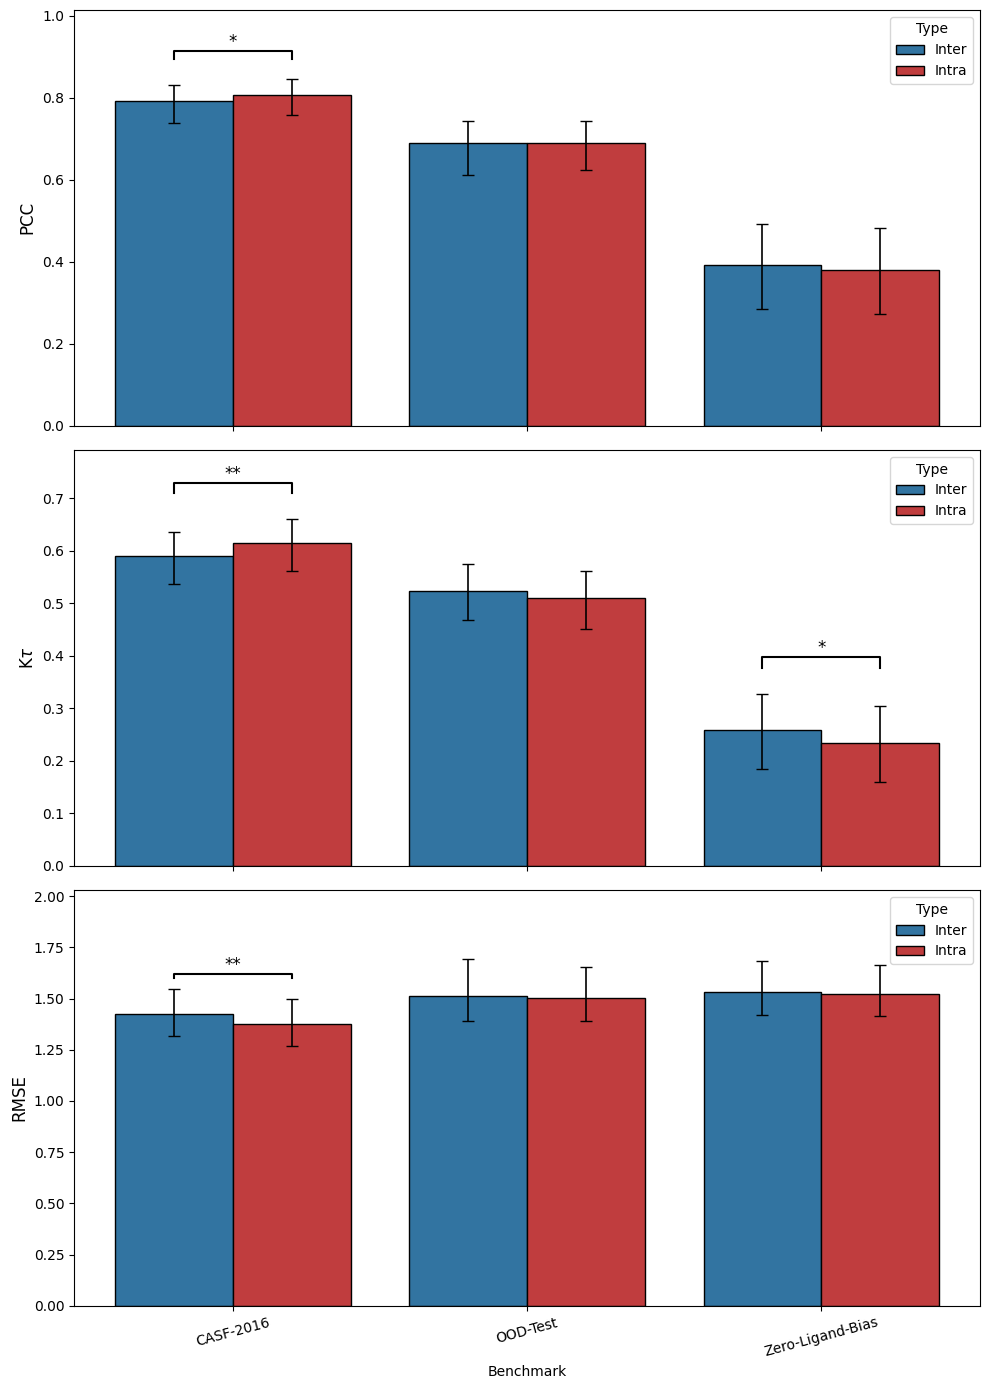

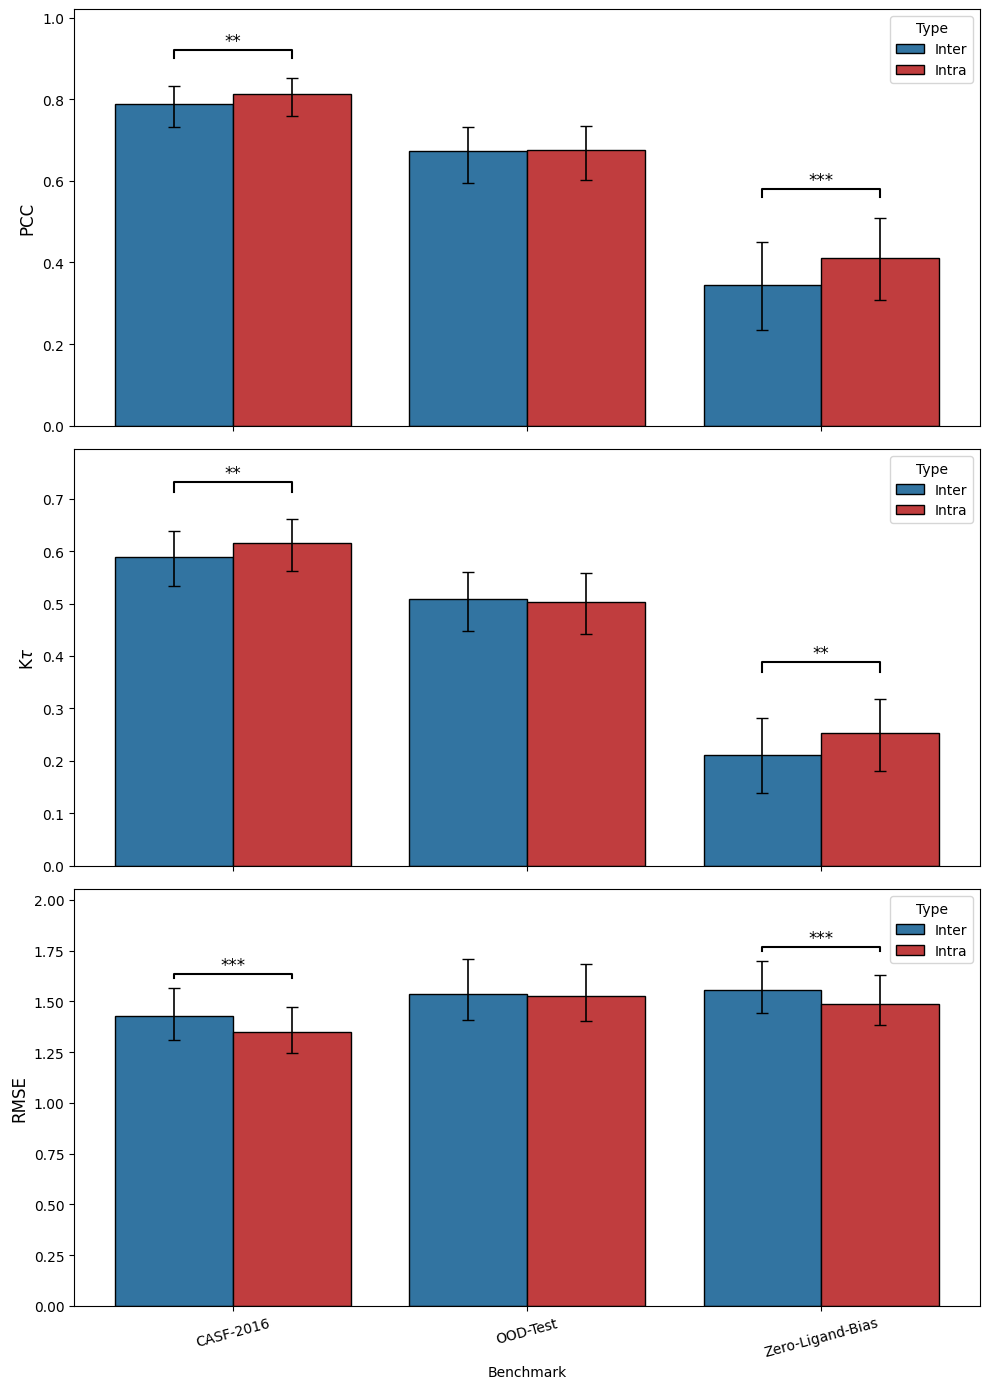

In [72]:
# Generate required plots
model_name_list = ["GATv2-H-3-L-5-Dim-256", "TAGCN-K-3-L-5-Dim-256"]
axes_list_list = [[1, 0, 1, 2], [0, 1, 2, 0, 1, 2]] # 0 is Pearson, 1 is Kendall, 2 is RMSE
target_index_list_list = [[2, 0, 0, 0], [2, 2, 2, 0, 0, 0]] # 0 is CASF-2016, 1 is OOD-Test, 2 is 0 Ligand Bias
anotation_list_list = [["*", "*", "**", "**"], ["***", "**", "***", "**", "**", "***"]] # * is <0.05, ** < 0.01, *** < 0.001

for model_name, axes_list, target_index_list, anotation_list in zip(model_name_list, axes_list_list, target_index_list_list, anotation_list_list):

    generate_comparison_bar_plot(model_name=model_name, title=f"{model_name} comparison bar plot", axes_list=axes_list, target_index_list=target_index_list, anotation_list=anotation_list)


In [73]:
import torch

state_dict_path = model_dir / "20260324_092900_GATv2-Drop-0-2-H-3-L-5-Dim-256-Inter-OOD-Test_model_2.pt" 
# Load a state_dict
state_dict = torch.load(state_dict_path, map_location="cpu", weights_only=False)

print(state_dict.keys())
print(state_dict["GNN_layers.0.lin_l.weight"].size())
print(state_dict["GNN_layers.0.att"])

odict_keys(['GNN_layers.0.att', 'GNN_layers.0.bias', 'GNN_layers.0.lin_l.weight', 'GNN_layers.0.lin_l.bias', 'GNN_layers.0.lin_r.weight', 'GNN_layers.0.lin_r.bias', 'GNN_layers.0.lin_edge.weight', 'GNN_layers.1.att', 'GNN_layers.1.bias', 'GNN_layers.1.lin_l.weight', 'GNN_layers.1.lin_l.bias', 'GNN_layers.1.lin_r.weight', 'GNN_layers.1.lin_r.bias', 'GNN_layers.1.lin_edge.weight', 'GNN_layers.2.att', 'GNN_layers.2.bias', 'GNN_layers.2.lin_l.weight', 'GNN_layers.2.lin_l.bias', 'GNN_layers.2.lin_r.weight', 'GNN_layers.2.lin_r.bias', 'GNN_layers.2.lin_edge.weight', 'GNN_layers.3.att', 'GNN_layers.3.bias', 'GNN_layers.3.lin_l.weight', 'GNN_layers.3.lin_l.bias', 'GNN_layers.3.lin_r.weight', 'GNN_layers.3.lin_r.bias', 'GNN_layers.3.lin_edge.weight', 'GNN_layers.4.att', 'GNN_layers.4.bias', 'GNN_layers.4.lin_l.weight', 'GNN_layers.4.lin_l.bias', 'GNN_layers.4.lin_r.weight', 'GNN_layers.4.lin_r.bias', 'GNN_layers.4.lin_edge.weight', 'BN_layers.0.module.weight', 'BN_layers.0.module.bias', 'BN_lay